Directory 'output' already exists.
Directory 'plots' already exists.


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 66 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 80 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


<Figure size 640x480 with 0 Axes>

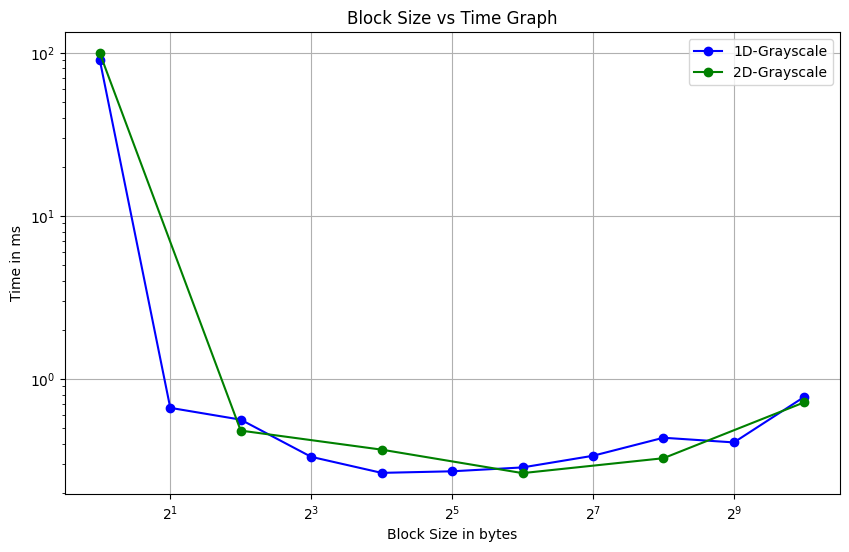

In [13]:
# HPC Labwork 4 : Threads
# by Lucien Elyas Bedrane - 2640012

#!pip install numba

import numba
import matplotlib.pyplot as plt
import numpy as np
import time
import os

from numba import cuda

def grayscale_CPU(src, dst):
 for i in range(0, len(src), 3):
  dst[i] = dst[i+1] = dst[i+2] = (src[i] + src[i+1] + src[i+2]) / 3

@cuda.jit
def grayscale_GPU_1D(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] * 255 + src[tidx,1] * 255 + src[tidx,2] * 255) / 3)
  dst[tidx,0] = dst[tidx,1] = dst[tidx,2] = g

@cuda.jit
def grayscale_GPU_2D(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  g = np.uint8((src[tidy, tidx, 0] * 255 + src[tidy, tidx, 1] * 255 + src[tidy, tidx, 2] * 255) / 3)
  dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

#We create folders the different outputs that we will generate
for directory_name in ["output", "plots"] :
  try:
      os.mkdir(directory_name)
      print(f"Directory '{directory_name}' created successfully.")
  except FileExistsError:
      print(f"Directory '{directory_name}' already exists.")
  except PermissionError:
      print(f"Permission denied: Unable to create '{directory_name}'.")
  except Exception as e:
      print(f"An error occurred: {e}")

#We load here the source image and flatten it to a 1D-array
img = plt.imread('src/cat.png')
image_src = np.reshape(img, (-1, 3))
pixelCount = image_src.shape[0]

#We initialize the blockSize and gridSize that will be used to test the 1D GPU version of grayscale
blockSize1D = [int(2**x) for x in range(11)]
gridSize1D = [int(np.ceil(pixelCount / x)) for x in blockSize1D]  #We use np.ceil to guarantee full pixel coverage if count isn't a multiple of block size

#We initialize the blockSize and gridSize that will be used to test the 2D GPU version of grayscale
blockSize2D = [(2**x, 2**x) for x in range(6)]
gridSize2D = [(int(np.ceil(img.shape[1] / x[0])), int(np.ceil(img.shape[0] / x[1]))) for x in blockSize2D]

#We copy here into the GPU memory the source image for the 1D GPU version of greyscale
devSrc = cuda.to_device(image_src)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

time_records_1D = []

#In this loop, we try the GPU version of grayscale_1D with different size of blocks and grids
for i in range(len(blockSize1D)):
    start_time = time.time()
    grayscale_GPU_1D[gridSize1D[i], blockSize1D[i]](devSrc, devDst)
    hostDst = devDst.copy_to_host()
    end_time = time.time()

    time_records_1D.append(end_time - start_time)

    output_image = np.reshape(hostDst, img.shape)
    plt.imsave("output/gpu_1D_output_" + str(i) + ".png", output_image)

time_records_2D = []

devSrc2D = cuda.to_device(img)
devDst2D = cuda.device_array(img.shape, np.uint8)

#In this loop, we try the GPU version of grayscale_2D with different size of blocks and grids
for i in range(len(blockSize2D)):
    start_time = time.time()
    grayscale_GPU_2D[gridSize2D[i], blockSize2D[i]](devSrc2D, devDst2D)
    hostDst2D = devDst2D.copy_to_host()
    end_time = time.time()

    time_records_2D.append(end_time - start_time)

    output_image = np.reshape(hostDst2D, img.shape)
    plt.imsave("output/gpu_2D_output_" + str(i) + ".png", output_image)

#We use the CPU version of grayscale
image_src_flat = image_src.flatten()
output_cpu = np.zeros(len(image_src_flat))
grayscale_CPU(image_src_flat, output_cpu)
cpu_image = np.reshape(output_cpu, img.shape)
plt.imsave("output/cpu_output.png", cpu_image)

#We convert the recorded time required for each loop of the GPU versions of grayscale
time_records_in_ms_1D = [t * 1000 for t in time_records_1D]
time_records_in_ms_2D = [t * 1000 for t in time_records_2D]

#We plot and save the graph of Block Size vs Time
plt.clf()
plt.figure(figsize=(10, 6))
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.plot(blockSize1D, time_records_in_ms_1D, linestyle="-", color="blue", marker="o", label="1D-Grayscale")
plt.plot([x[0]**2 for x in blockSize2D], time_records_in_ms_2D, linestyle="-", color="green", marker="o", label="2D-Grayscale")
plt.legend()
plt.title("Block Size vs Time Graph")
plt.xlabel("Block Size in bytes")
plt.ylabel("Time in ms")
plt.grid(True)
plt.savefig("plots/BlockSize_vs_Time_Graph.png")